In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [3]:
train_dataset = torchvision.datasets.FashionMNIST(root="./data", train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.FashionMNIST(root="./data", train=False, transform=transform, download=True)

100%|██████████| 26.4M/26.4M [00:01<00:00, 21.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 342kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 6.35MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.59MB/s]


In [4]:
image, label = train_dataset[0]
print(image.shape)
print(len(train_dataset))


torch.Size([1, 28, 28])
60000


In [5]:
image, label = test_dataset[0]
print(image.shape)
print(len(test_dataset))

torch.Size([1, 28, 28])
10000


In [6]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [7]:
class CNNClassifier(nn.Module):
    def __init__(self):
        super(CNNClassifier, self).__init__()
        # Convolutional layers
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully connected layers
        self.fc1 = nn.Linear(32 * 7 * 7, 128) # Calculate the input size after pooling
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 10) # 10 output classes for MNIST

    def forward(self, x):
        # Forward pass through convolutional layers
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))

        # Flatten the output for fully connected layers
        x = x.view(-1, 32 * 7 * 7) # Reshape the tensor

        # Forward pass through fully connected layers
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)

        return x


In [8]:
# Initialize model, loss function, and optimizer
model = CNNClassifier()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [9]:
# Train the Model
def train_model(model, train_loader, num_epochs=3):
    model.train() # Set the model to training mode

    for epoch in range(num_epochs):
        running_loss = 0.0
        for i, (images, labels) in enumerate(train_loader):
            # Move tensors to the configured device
            if torch.cuda.is_available():
                device = torch.device("cuda")
                images = images.to(device)
                labels = labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print('Name: PRAJAN P')
        print('Register Number: 212223240121')
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}')

In [10]:
train_model(model, train_loader)

Name: PRAJAN P
Register Number: 212223240121
Epoch [1/3], Loss: 0.4411
Name: PRAJAN P
Register Number: 212223240121
Epoch [2/3], Loss: 0.2937
Name: PRAJAN P
Register Number: 212223240121
Epoch [3/3], Loss: 0.2472


In [11]:
def test_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total
    print('Name:PRAJAN P')
    print('Register Number:212223240121')
    print(f'Test Accuracy: {accuracy:.4f}')

    # Compute confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    print('Name:PRAJAN P')
    print('Register Number:212223240121')
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_dataset.classes, yticklabels=test_dataset.classes)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    # Print classification report
    print('Name:PRAJAN P')
    print('Register Number:212223240121')
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))

Name:PRAJAN P
Register Number:212223240121
Test Accuracy: 0.9040
Name:PRAJAN P
Register Number:212223240121


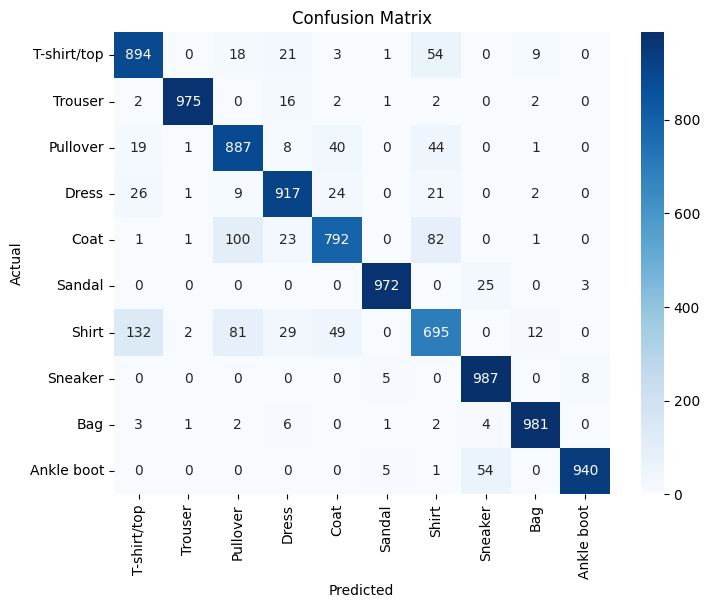

Name:PRAJAN P
Register Number:212223240121
Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.83      0.89      0.86      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.81      0.89      0.85      1000
       Dress       0.90      0.92      0.91      1000
        Coat       0.87      0.79      0.83      1000
      Sandal       0.99      0.97      0.98      1000
       Shirt       0.77      0.69      0.73      1000
     Sneaker       0.92      0.99      0.95      1000
         Bag       0.97      0.98      0.98      1000
  Ankle boot       0.99      0.94      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [12]:
test_model(model, test_loader)

In [13]:
import matplotlib.pyplot as plt
def predict_image(model, image_index, dataset):
    model.eval()
    image, label = dataset[image_index]
    with torch.no_grad():
        output = model(image.unsqueeze(0))  # Add batch dimension
        _, predicted = torch.max(output, 1)
    class_names = dataset.classes

    # Display the image
    print('Name:PRAJAN P')
    print('Register Number:212223240121')
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(f'Actual: {class_names[label]}\nPredicted: {class_names[predicted.item()]}')
    plt.axis("off")
    plt.show()
    print(f'Actual: {class_names[label]}, Predicted: {class_names[predicted.item()]}')


Name:PRAJAN P
Register Number:212223240121


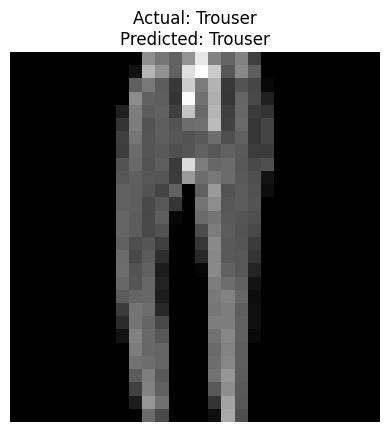

Actual: Trouser, Predicted: Trouser


In [14]:
predict_image(model, image_index=80, dataset=test_dataset)